# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari Kaggle (https://www.kaggle.com/datasets/mahdimashayekhi/mental-health)

    Pada eksperimen ini digunakan dataset **Mental Health Survey Dataset** yang berisi data survei sintetis mengenai kondisi kesehatan mental individu di lingkungan kerja. Dataset ini terdiri dari **10.000 data dengan 14 atribut**.

    - age: usia responden dalam satuan tahun
    - gender: identitas gender responden (Male, Female, Non-binary)
    - employment_status: status pekerjaan responden (Employed, Unemployed, Student)
    - work_environment: jenis lingkungan kerja (On-site, Remote, Hybrid)
    - mental_health_history: riwayat kesehatan mental sebelumnya (True/False)
    - seeks_treatment: status apakah individu mencari perawatan kesehatan mental (True/False)
    - stress_level: tingkat stres individu
    - sleep_hours: rata-rata jam tidur per hari
    - physical_activity_days: jumlah hari aktivitas fisik dalam satu minggu
    - depression_score: skor indikasi depresi
    - anxiety_score: skor indikasi kecemasan
    - social_support_score: skor dukungan sosial yang diterima individu
    - productivity_score: skor produktivitas individu
    - mental_health_risk: tingkat risiko kesehatan mental (Low, Medium, High)

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
df = pd.read_csv('mental.csv')

df.head()

,age,gender,employment_status,work_environment,mental_health_history,seeks_treatment,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score,mental_health_risk
0,56,Male,Employed,On-site,Yes,Yes,6,6.2,3,28,17,54,59.7,High
1,46,Female,Student,On-site,No,Yes,10,9.0,4,30,11,85,54.9,High
2,32,Female,Employed,On-site,Yes,No,7,7.7,2,24,7,62,61.3,Medium
3,60,Non-binary,Self-employed,On-site,No,No,4,4.5,4,6,0,95,97.0,Low
4,25,Female,Self-employed,On-site,Yes,Yes,3,5.4,0,24,12,70,69.0,High


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     10000 non-null  int64  
 1   gender                  10000 non-null  object 
 2   employment_status       10000 non-null  object 
 3   work_environment        10000 non-null  object 
 4   mental_health_history   10000 non-null  object 
 5   seeks_treatment         10000 non-null  object 
 6   stress_level            10000 non-null  int64  
 7   sleep_hours             10000 non-null  float64
 8   physical_activity_days  10000 non-null  int64  
 9   depression_score        10000 non-null  int64  
 10  anxiety_score           10000 non-null  int64  
 11  social_support_score    10000 non-null  int64  
 12  productivity_score      10000 non-null  float64
 13  mental_health_risk      10000 non-null  object 
dtypes: float64(2), int64(6), object(6)
memo

In [4]:
df.describe()

,age,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,41.557600,5.572000,6.473000,3.505700,15.039900,10.56180,50.117700,77.312210
std,13.749581,2.887741,1.473944,2.282737,8.990839,6.32264,29.229278,14.061202
min,18.000000,1.000000,3.000000,0.000000,0.000000,0.00000,0.000000,42.800000
25%,30.000000,3.000000,5.500000,2.000000,7.000000,5.00000,25.000000,65.800000
50%,41.500000,6.000000,6.500000,4.000000,15.000000,11.00000,50.000000,77.600000
75%,53.000000,8.000000,7.500000,5.000000,23.000000,16.00000,76.000000,89.200000
max,65.000000,10.000000,10.000000,7.000000,30.000000,21.00000,100.000000,100.000000


In [6]:
df.isnull().sum()

,0
age,0
gender,0
employment_status,0
work_environment,0
mental_health_history,0
seeks_treatment,0
stress_level,0
sleep_hours,0
physical_activity_days,0
depression_score,0


In [7]:
print(
    "Jumlah duplicate:",
    df.duplicated().sum()
)

Jumlah duplicate: 0


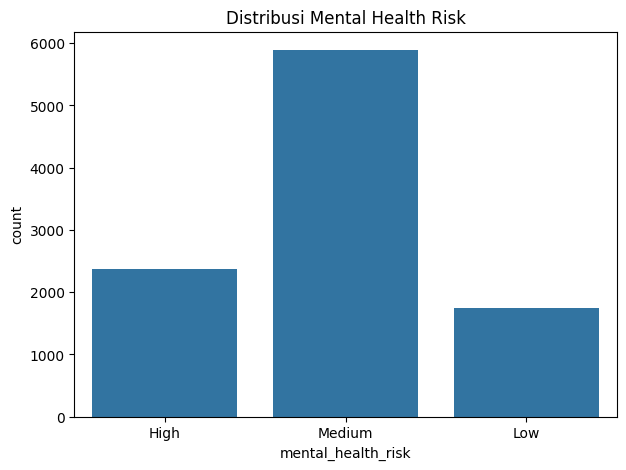

In [8]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='mental_health_risk',
    data=df
)

plt.title(
    'Distribusi Mental Health Risk'
)

plt.show()

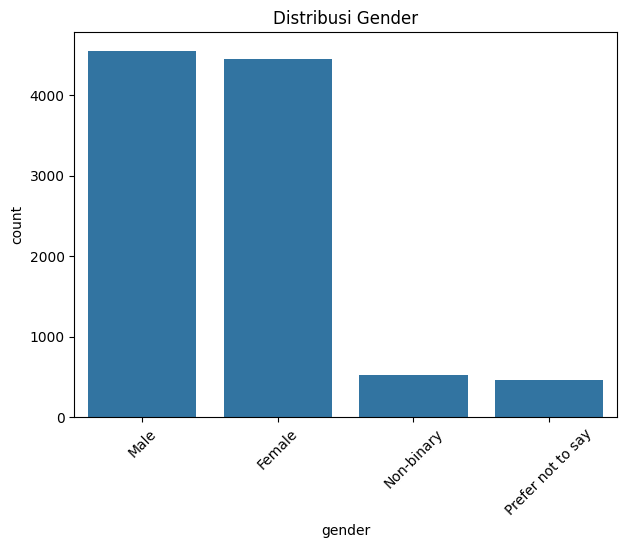

In [9]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='gender',
    data=df
)

plt.title('Distribusi Gender')

plt.xticks(rotation=45)

plt.show()

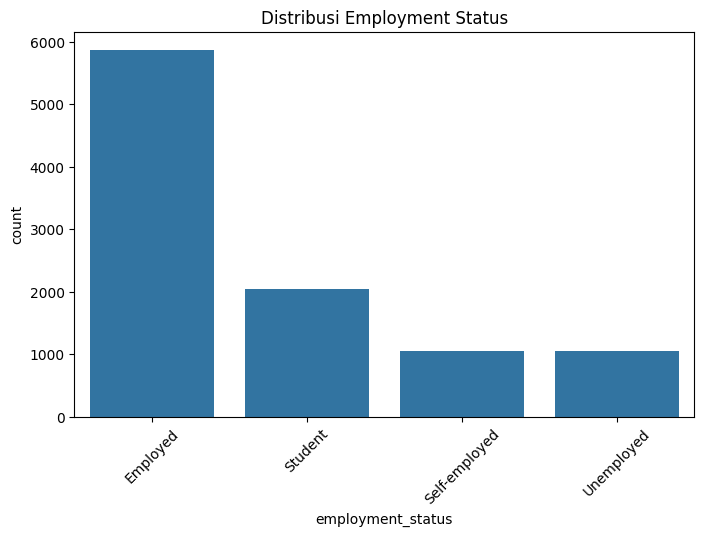

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='employment_status',
    data=df
)

plt.title('Distribusi Employment Status')

plt.xticks(rotation=45)

plt.show()

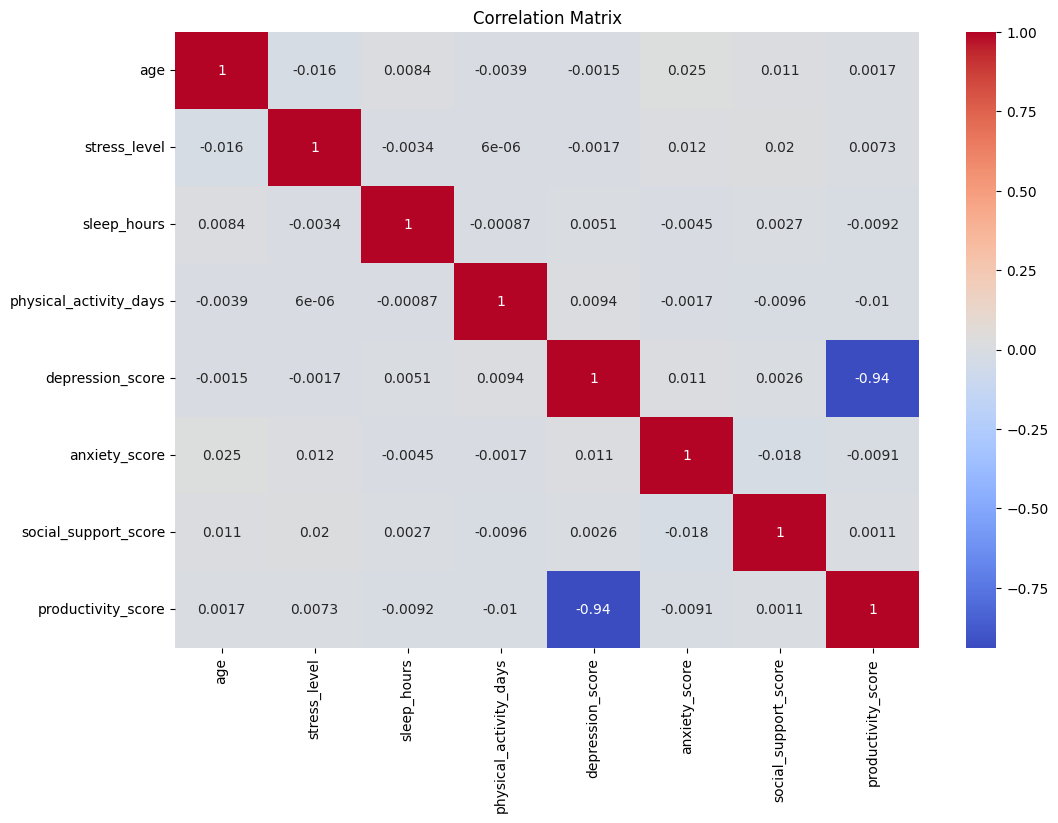

In [13]:
numeric_cols = [
    'age',
    'stress_level',
    'sleep_hours',
    'physical_activity_days',
    'depression_score',
    'anxiety_score',
    'social_support_score',
    'productivity_score'
]

plt.figure(figsize=(12,8))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

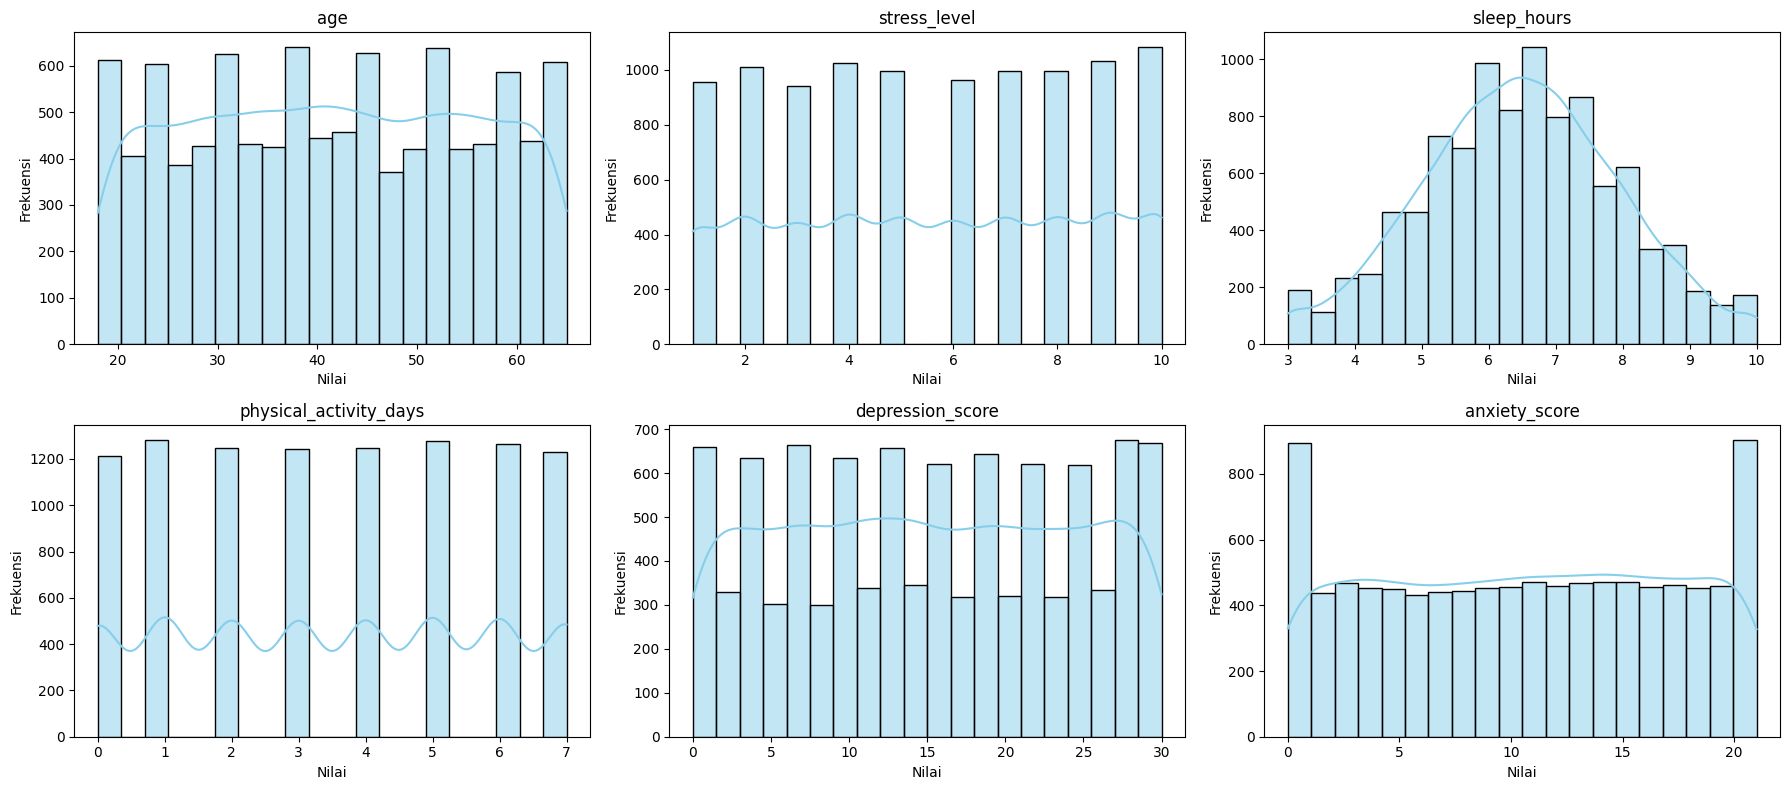

In [14]:
# Menampilkan histogram untuk semua kolom numerik

numerical_cols = [
    'age',
    'stress_level',
    'sleep_hours',
    'physical_activity_days',
    'depression_score',
    'anxiety_score'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

axes = axes.flatten()

for i, column in enumerate(numerical_cols):

    # histogram
    sns.histplot(
        df[column],
        bins=20,
        kde=True,
        color='skyblue',
        ax=axes[i]
    )

    # title dan label
    axes[i].set_title(column)

    axes[i].set_xlabel("Nilai")

    axes[i].set_ylabel("Frekuensi")

plt.tight_layout()

plt.show()

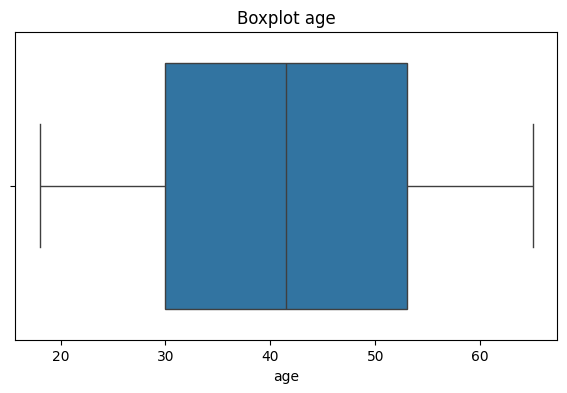

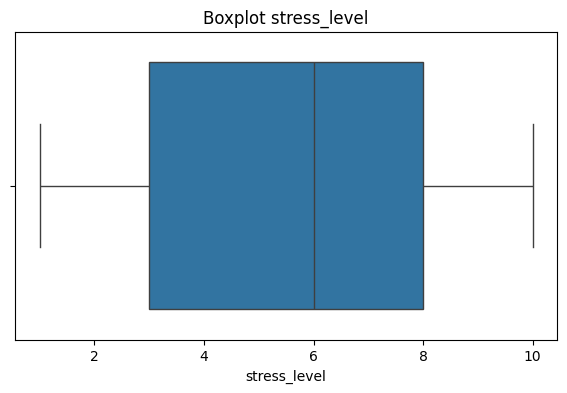

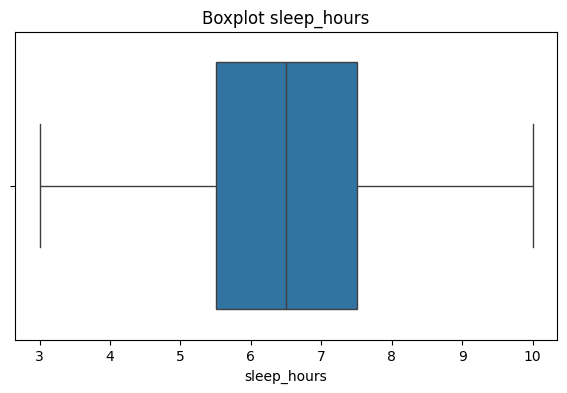

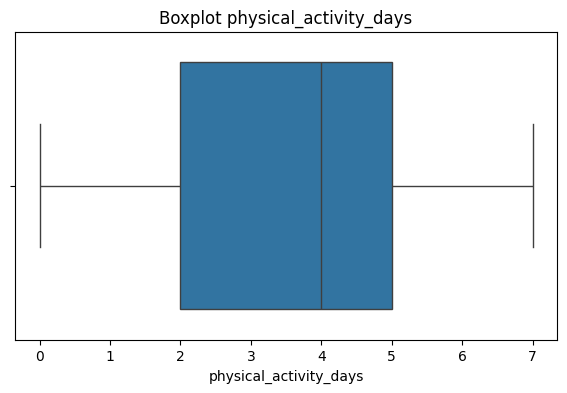

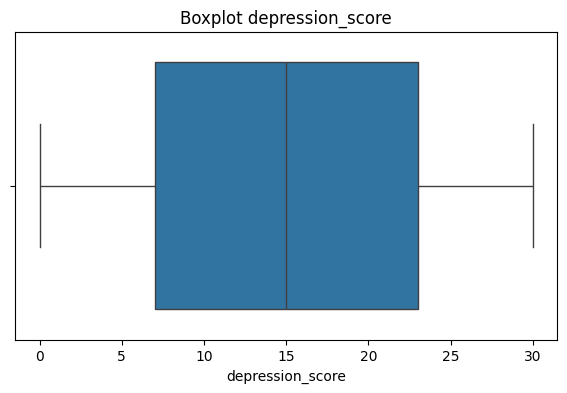

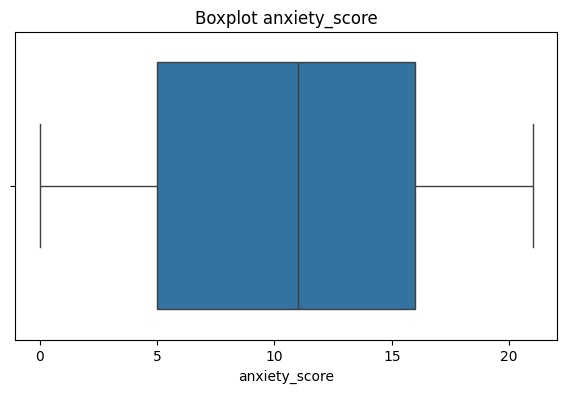

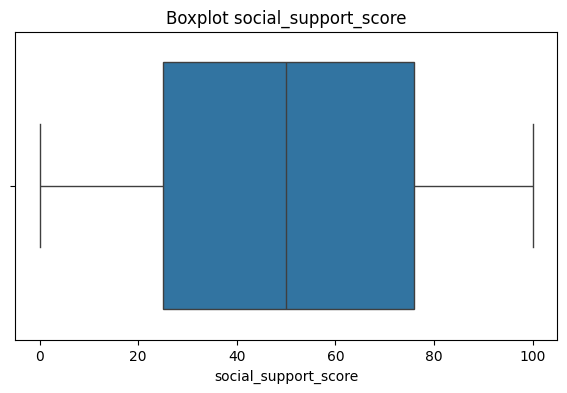

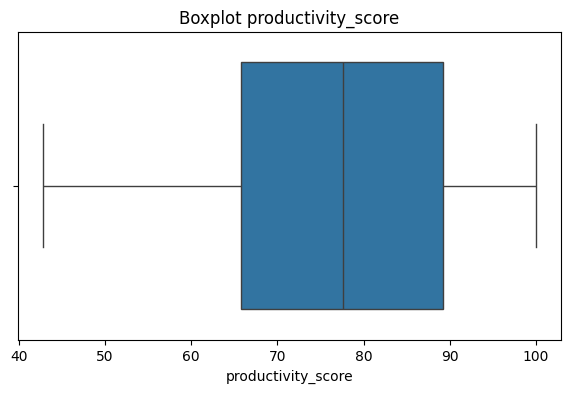

In [15]:
for col in numeric_cols:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f'Boxplot {col}')

    plt.show()

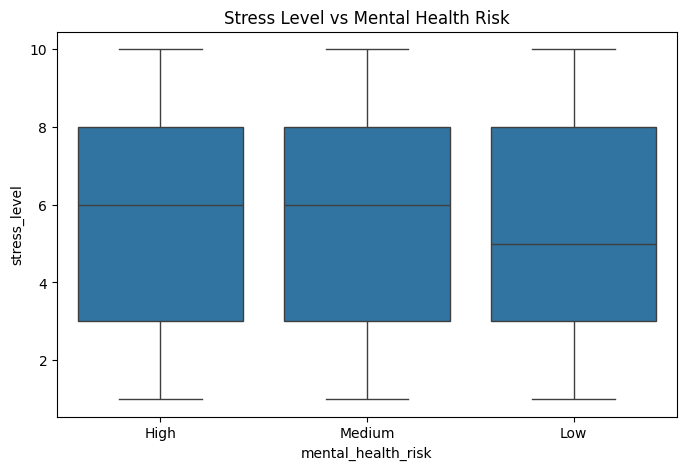

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='mental_health_risk',
    y='stress_level',
    data=df
)

plt.title(
    'Stress Level vs Mental Health Risk'
)

plt.show()

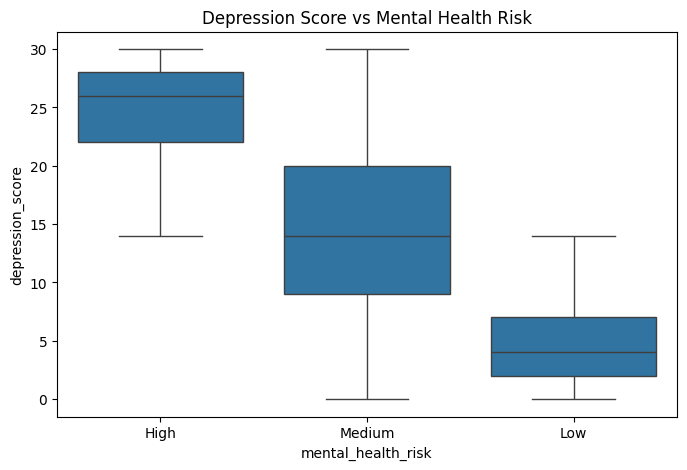

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='mental_health_risk',
    y='depression_score',
    data=df
)

plt.title(
    'Depression Score vs Mental Health Risk'
)

plt.show()

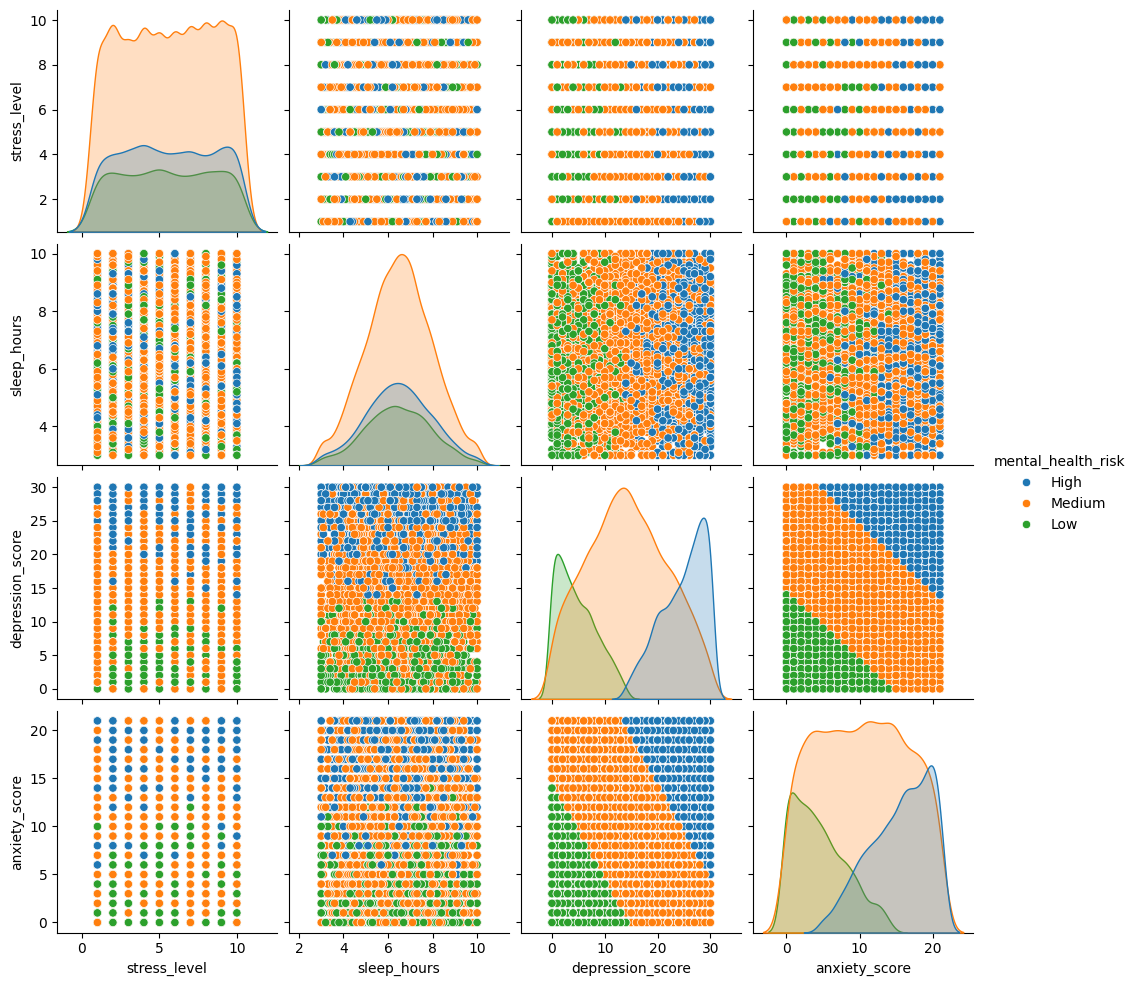

In [18]:
sns.pairplot(
    df[
        [
            'stress_level',
            'sleep_hours',
            'depression_score',
            'anxiety_score',
            'mental_health_risk'
        ]
    ],
    hue='mental_health_risk'
)

plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [21]:
df.isnull().sum()

,0
age,0
gender,0
employment_status,0
work_environment,0
mental_health_history,0
seeks_treatment,0
stress_level,0
sleep_hours,0
physical_activity_days,0
depression_score,0


In [23]:
df = df.drop_duplicates()

print("After duplicates removal:", df.shape)

After duplicates removal: (10000, 14)


In [24]:
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower) &
        (df[col] <= upper)
    ]

print("Outlier berhasil ditangani")

print(df.shape)

Outlier berhasil ditangani
(10000, 14)


In [25]:
bins = [0, 18, 30, 45, 60, 100]

labels = [
    'Teen',
    'Young Adult',
    'Adult',
    'Middle Age',
    'Senior'
]

df['age_group'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels
)

df[['age', 'age_group']].head()

,age,age_group
0,56,Middle Age
1,46,Middle Age
2,32,Adult
3,60,Middle Age
4,25,Young Adult


In [26]:
categorical_cols = [
    'gender',
    'employment_status',
    'work_environment',
    'mental_health_history',
    'seeks_treatment',
    'mental_health_risk',
    'age_group'
]

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(
        df[col]
    )

df.head()

,age,gender,employment_status,work_environment,mental_health_history,seeks_treatment,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score,mental_health_risk,age_group
0,56,1,0,1,1,1,6,6.2,3,28,17,54,59.7,0,1
1,46,0,2,1,0,1,10,9.0,4,30,11,85,54.9,0,1
2,32,0,0,1,1,0,7,7.7,2,24,7,62,61.3,2,0
3,60,2,1,1,0,0,4,4.5,4,6,0,95,97.0,1,1
4,25,0,1,1,1,1,3,5.4,0,24,12,70,69.0,0,4


In [27]:
X = df.drop(
    'mental_health_risk',
    axis=1
)

y = df['mental_health_risk']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

processed_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

processed_df[
    'mental_health_risk'
] = y.values

processed_df.head()

,age,gender,employment_status,work_environment,mental_health_history,seeks_treatment,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score,age_group,mental_health_risk
0,1.050441,0.389964,-0.761146,-0.152601,1.516325,1.227812,0.148220,-0.185227,-0.221543,1.441550,1.018328,0.132829,-1.252602,-0.361962,0
1,0.323110,-0.907753,1.081153,-0.152601,-0.659489,1.227812,1.533455,1.714534,0.216549,1.664010,0.069310,1.193462,-1.593984,-0.361962,0
2,-0.695154,-0.907753,-0.761146,-0.152601,1.516325,-0.814457,0.494529,0.832502,-0.659636,0.996631,-0.563369,0.406541,-1.138808,-1.006942,2
3,1.341373,1.687681,0.160004,-0.152601,-0.659489,-0.814457,-0.544397,-1.338653,0.216549,-1.005507,-1.670557,1.535602,1.400220,-0.361962,1
4,-1.204286,-0.907753,0.160004,-0.152601,1.516325,1.227812,-0.890706,-0.728015,-1.535821,0.996631,0.227480,0.680253,-0.591175,1.572976,0


In [28]:
processed_df.to_csv(
    'mental_clean.csv',
    index=False
)

print("Dataset preprocessing berhasil disimpan!")

Dataset preprocessing berhasil disimpan!
